In [347]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['AppleGothic']


# C-MAPSS

Kaggle에서 원본 다운로드 가능
https://www.kaggle.com/datasets/canyiduan/nasa-c-mapss$0

NASA의 **C-MAPSS(Commercial Modular Aero-Propulsion System Simulation) 데이터셋**은 항공기 터보팬 엔진의 열화 및 고장 과정을 시뮬레이션하여 생성한 대표적인 시계열 벤치마크 데이터셋입니다. 산업 인공지능 분야의 **예지보전(Predictive Maintenance, PdM)** 및 **잔여 수명 예측(RUL, Remaining Useful Life)** 연구에서 사실상의 표준(De facto standard)으로 널리 쓰입니다.

---

**1. 데이터 개요 및 구성**

* **데이터 형태:** 다변량 시계열(Multivariate Time-series) 데이터
* **기록 변수:** 엔진 ID, 운용 사이클(Time/Cycle), 운용 설정값 3종(고도, 마하 수, 스로틀 등), 센서 측정값 21종(온도, 압력, 팬 속도 등)
* **기본 구조:** 엔진이 정상 상태에서 가동을 시작해 시간이 지남에 따라 점진적으로 마모되어 완전한 고장(Failure)에 도달할 때까지의 데이터가 사이클 단위로 기록되어 있습니다.

**2. 4가지 서브 데이터셋 (FD001 ~ FD004)**
C-MAPSS는 운용 환경과 고장 모드 조합에 따라 난이도가 다른 4개의 하위 데이터셋으로 나뉩니다.

| 데이터셋 | 운용 조건 수 (Conditions) | 고장 모드 (Fault Modes) | 난이도 / 특징 |
| --- | --- | --- | --- |
| **FD001** | 1개 (해수면 고정) | 1개 (HPC 열화) | 가장 단순한 베이스라인 |
| **FD002** | 6개 (복합 비행 조건) | 1개 (HPC 열화) | 다양한 운용 환경 반영 |
| **FD003** | 1개 (해수면 고정) | 2개 (HPC + Fan 열화) | 복수 고장 원인 분석 |
| **FD004** | 6개 (복합 비행 조건) | 2개 (HPC + Fan 열화) | 실제와 가장 유사한 복합 조건 |

*(HPC: High Pressure Compressor, 고압 압축기)*

**3. 연구 활용 목적**

* **RUL(잔여 수명) 예측:** 테스트 셋의 엔진이 고장나기 전까지 몇 사이클이 더 남아있는지 추정.
* **이상 탐지 및 고장 진단:** 정상 신호 패턴에서 벗어나는 시점을 조기에 감지하고 고장 모드를 분류.

## 실습 1. C-MAPSS 데이터 열고 구조 확인
### 목표
강사가 준 엔진 데이터를 직접 열어 크기와 열 구성을 파악
### 단계
- pandas를 불러와 샘플 파일을 데이터프레임으로 열기
- 크기 속성으로 행·열 개수를, 열 이름 속성으로 컬럼을 확인
- 앞부분을 미리 보며 값의 모양을 눈으로 익히기
### 예상 결과
행 천여 개·스물여섯 열, 엔진번호·작동회차·센서 열이 보임

In [348]:
df = pd.read_csv("data/20_cmapss_fd001_sample.csv")
print(df.shape)
print(df.columns)

# 결측 확인
print(df.isna().sum().sum())

(1116, 26)
Index(['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1',
       's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11',
       's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20',
       's_21'],
      dtype='str')
0


## 실습 2. 엔진 단위와 작동 길이 파악
### 목표
데이터에 여러 엔진이 섞여 있음을 확인하고 엔진별 작동 길이를 파악
### 단계
- 엔진번호의 고유값 개수로 엔진이 몇 대인지 세기
- 엔진번호별 행 수를 세어 각 엔진의 작동 회차 길이를 구하기
- 번호 순으로 정렬해 엔진마다 길이가 다름을 확인
### 예상 결과
엔진 다섯 대, 엔진별 회차 수가 179~287로 서로 다름

In [349]:
print("엔진 대수 :", df["unit_nr"].nunique()) # nunique() : 중복 제외 고윳값 개수 확인 

print("엔진별 사이클 기록 갯수")
print(df["unit_nr"].value_counts())

엔진 대수 : 5
엔진별 사이클 기록 갯수
unit_nr
2    287
5    269
1    192
4    189
3    179
Name: count, dtype: int64


## 실습 3. 요약 통계로 센서 범위 읽기
### 목표
요약 통계로 주요 센서의 평균과 값 범위를 수치로 파악
### 단계
- 2번 엔진을 골라 세 센서의 요약 통계를 한 번에 보기
- 평균으로 대략 크기를, 흔들림 폭으로 변동 정도를 읽기
- 최소·최대로 각 센서의 값 범위가 서로 다름을 확인
### 예상 결과
세 센서의 평균이 약 641.8·47.7·517.4로 크기가 제각각

In [350]:
engine = df[df["unit_nr"] == 2]
print(engine[["s_2", "s_12", "s_18"]].describe())

              s_2        s_12    s_18
count  287.000000  287.000000   287.0
mean   641.752997  517.430105  2388.0
std      0.486257    2.146613     0.0
min    640.460000  512.860000  2388.0
25%    641.390000  515.655000  2388.0
50%    641.700000  517.230000  2388.0
75%    642.140000  519.155000  2388.0
max    642.870000  521.960000  2388.0


## 실습 4. 변하는 센서 선별과 결측 확인
### 목표
거의 변하지 않는 센서를 빼고 분석에 쓸 센서를 직접 선별
### 단계
- 여러 센서의 흔들림 폭을 비교해 0에 가까운 것은 제외 대상으로 표시
- 뚜렷이 변하는 센서를 분석 대상으로 남기기
- 결측 합계를 세어 빈 값이 없는지 확인
### 예상 결과
첫 두 센서는 값이 늘 같아 제외, 뒤 센서는 변함, 결측 없음

In [351]:
sensors = ["s_1", "s_3", "s_8", "s_10", "s_13"]

for sensor in sensors:
    print(sensor, round(df[sensor].std(), 3))
print("-" * 20)
print("결측 합계: ", df.isna().sum().sum())

s_1 0.0
s_3 4.573
s_8 0.099
s_10 0.0
s_13 0.076
--------------------
결측 합계:  0


## 실습 5. 엔진 하나 골라 첫·끝 추세 읽기
### 목표
엔진 하나를 골라 회차 순으로 정렬하고 첫·끝 값으로 추세 방향을 읽기
### 단계
- 2번 엔진만 골라 작동 회차 순으로 정렬
- 상승 센서와 하강 센서의 첫 회차 값과 마지막 값을 꺼내기
- 첫 값과 끝 값을 비교해 상승인지 하강인지 판정
### 예상 결과
한 센서는 47.30에서 48.18로 상승, 다른 센서는 하강

In [352]:
engine_sorted = df[df["unit_nr"] == 2].sort_values("time_cycles")
print(engine_sorted.head(2))

# 상승 센서 : s_11 / 하강센서 : s_7

print(engine_sorted[["time_cycles","s_11", "s_7"]].head())
print(engine_sorted[["time_cycles","s_11", "s_7"]].tail())

     unit_nr  time_cycles  setting_1  setting_2  setting_3     s_1     s_2  \
192        2            1     0.0013     0.0006      100.0  518.67  640.79   
193        2            2     0.0001    -0.0006      100.0  518.67  641.23   

         s_3      s_4    s_5  ...    s_12     s_13     s_14   s_15  s_16  \
192  1583.91  1400.99  14.62  ...  520.52  2388.07  8144.09  8.405  0.03   
193  1580.40  1406.14  14.62  ...  519.71  2388.07  8134.16  8.366  0.03   

     s_17  s_18   s_19   s_20     s_21  
192   392  2388  100.0  38.94  23.2552  
193   391  2388  100.0  39.03  23.2492  

[2 rows x 26 columns]
     time_cycles   s_11     s_7
192            1  47.30  553.84
193            2  47.39  553.82
194            3  47.26  554.58
195            4  47.36  553.35
196            5  47.19  554.16
     time_cycles   s_11     s_7
474          283  48.31  545.58
475          284  48.00  546.77
476          285  48.10  546.32
477          286  48.17  545.93
478          287  48.18  546.17


In [353]:
for i in ["s_11", "s_7"] :
    start = engine_sorted[i].iloc[0]
    end = engine_sorted[i].iloc[-1]
    print(f"{i} 데이터는 {start}로 시작해 {end}로 끝난다. ")

s_11 데이터는 47.3로 시작해 48.18로 끝난다. 
s_7 데이터는 553.84로 시작해 546.17로 끝난다. 


## 실습 6. 엔진 센서 시계열 그래프 그리기
### 목표
정렬한 엔진 데이터로 회차를 가로축, 센서를 세로축으로 선 그래프 그리기
### 단계
- 상승 센서를 선 그래프로 그리고 제목·축 이름 붙이기
- 하강 센서도 같은 방식으로 그려 방향을 비교
- 두 그래프의 기울기 방향으로 추세를 눈으로 확인
### 예상 결과
한 센서는 우상향, 다른 센서는 우하향 곡선

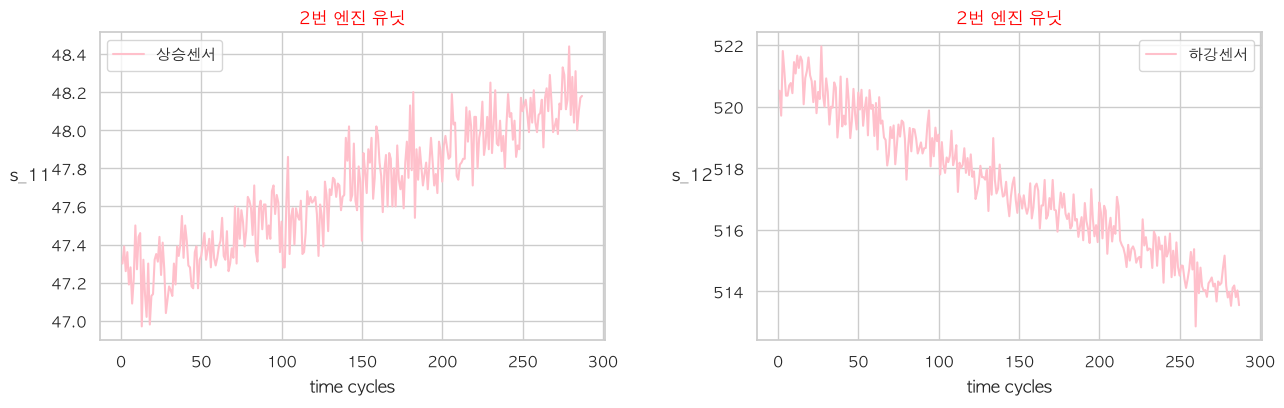

In [354]:
# 상승 센서 : s_11 / 하강센서 : s_7, s_12

plt.figure(figsize=(15,4))
plt.subplots_adjust(wspace=0.3)

plt.subplot(1, 2, 1)
plt.title("2번 엔진 유닛", color = "red")
plt.plot(engine_sorted["time_cycles"], engine_sorted["s_11"], label = "상승센서", color = "pink")
plt.xlabel("time cycles")
plt.ylabel("s_11", rotation = 0, labelpad=15)
plt.legend()

plt.subplot(1, 2, 2)
plt.title("2번 엔진 유닛", color = "red")
plt.plot(engine_sorted["time_cycles"], engine_sorted["s_12"], label = "하강센서", color = "pink")
plt.xlabel("time cycles")
plt.ylabel("s_12", rotation = 0, labelpad=15)
plt.legend()


plt.show()

## 실습 7. 여러 센서 비교와 범위 문제
### 목표
여러 센서를 함께 그려 비교하고 값 범위가 다를 때의 문제를 체험
### 단계
- 크기가 비슷한 두 센서를 함께 그리고 범례를 붙여 비교
- 크기가 크게 다른 두 센서를 일부러 겹쳐 그리기
- 두 센서의 범위를 숫자로 확인해 작은 값이 왜 안 보이는지 이해
### 예상 결과
약 8100 센서에 가려 약 38 센서가 평평하게 보임

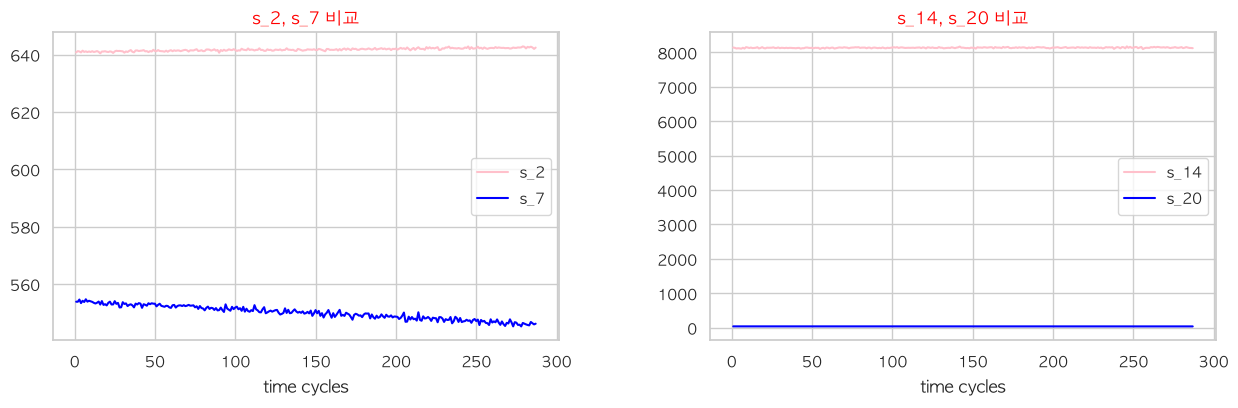

In [355]:
# s_2, s_7 : 비슷
# s_14, s_20 : 다름

plt.figure(figsize=(15,4))
plt.subplots_adjust(wspace=0.3)

plt.subplot(1, 2, 1)
plt.title("s_2, s_7 비교", color = "red")
plt.plot(engine_sorted["time_cycles"], engine_sorted["s_2"], label = "s_2", color = "pink")
plt.plot(engine_sorted["time_cycles"], engine_sorted["s_7"], label = "s_7", color = "blue")
plt.xlabel("time cycles")
plt.legend()

plt.subplot(1, 2, 2)
plt.title("s_14, s_20 비교", color = "red")
plt.plot(engine_sorted["time_cycles"], engine_sorted["s_14"], label = "s_14", color = "pink")
plt.plot(engine_sorted["time_cycles"], engine_sorted["s_20"], label = "s_20", color = "blue")
plt.xlabel("time cycles")
plt.legend()


plt.show()

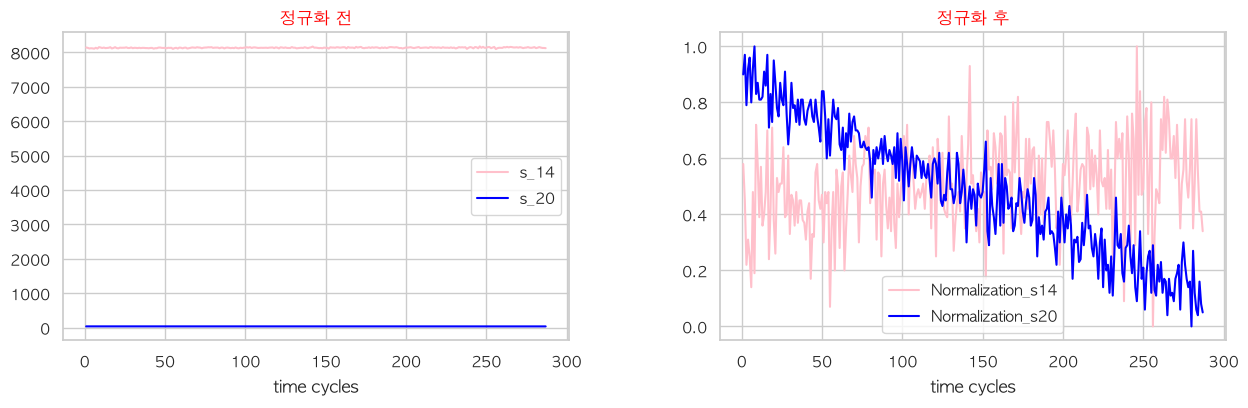

In [356]:
# 정규화 
engine_sorted["Normalization_s14"] = round(((engine_sorted["s_14"] -engine_sorted["s_14"].min()) / (engine_sorted["s_14"].max() - engine_sorted["s_14"].min())),2)
engine_sorted["Normalization_s20"] = round(((engine_sorted["s_20"] -engine_sorted["s_20"].min()) / (engine_sorted["s_20"].max() - engine_sorted["s_20"].min())),2)

plt.figure(figsize=(15,4))
plt.subplots_adjust(wspace=0.3)

plt.subplot(1, 2, 1)
plt.title("정규화 전", color = "red")
plt.plot(engine_sorted["time_cycles"], engine_sorted["s_14"], label = "s_14", color = "pink")
plt.plot(engine_sorted["time_cycles"], engine_sorted["s_20"], label = "s_20", color = "blue")
plt.xlabel("time cycles")
plt.legend()

plt.subplot(1, 2, 2)
plt.title("정규화 후", color = "red")
plt.plot(engine_sorted["time_cycles"], engine_sorted["Normalization_s14"], label = "Normalization_s14", color = "pink")
plt.plot(engine_sorted["time_cycles"], engine_sorted["Normalization_s20"], label = "Normalization_s20", color = "blue")
plt.xlabel("time cycles")
plt.legend()


plt.show()



## 실습 8. 데이터 구조 미니 리포트
### 목표
오늘 확인한 크기·엔진·센서 특성을 짧은 리포트로 자동 정리
### 단계
- 전체 크기와 엔진 대수를 한 줄로 출력
- 대상 엔진의 작동 회차 수와 결측 유무를 정리
- 주목 센서 세 개의 첫·끝 방향을 반복문으로 표처럼 정리
### 예상 결과
크기·엔진 수·회차·결측·센서 방향이 담긴 짧은 명세 리포트

In [357]:
print(f"전체크기 : {df.shape}")
print(f"엔진대수 : {df["unit_nr"].nunique()}대")
print(f"데이터유실 : {df.isna().sum().sum()}개")

print("="*20)

target = 2
print(f"대상엔진 : {target}")

engine2 = df[df["unit_nr"] == target]
print(f"엔진 {target} : {len(engine2)}회차 기록")
print(f"엔진 {target} 결측치 : {engine2.isna().sum().sum()}개")

    

전체크기 : (1116, 26)
엔진대수 : 5대
데이터유실 : 0개
대상엔진 : 2
엔진 2 : 287회차 기록
엔진 2 결측치 : 0개


## 실습 1. 문자열 날짜를 시간으로 변환
### 목표
글자로 읽힌 날짜를 진짜 시간 값으로 바꾸기
### 단계
- 샘플을 열고 시간 열의 자료형을 먼저 확인
- 시간 변환 함수로 글자를 시간 값으로 바꾸기
- 바뀐 자료형을 다시 확인해 변환 성공을 확인
### 예상 결과
자료형이 글자에서 시간 형식으로 바뀜

In [358]:
data = pd.read_csv("data/20_engine01_timestamp_sample.csv", encoding = "UTF-8")

print(data.shape)
data.info()

(182, 6)
<class 'pandas.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  182 non-null    str    
 1   temp_out   182 non-null    float64
 2   temp_core  182 non-null    float64
 3   pressure   180 non-null    float64
 4   vibration  179 non-null    float64
 5   flow       182 non-null    float64
dtypes: float64(5), str(1)
memory usage: 8.7 KB


In [359]:
print(f"원래 TimeStamp 컬럼의 타입은 {data["timestamp"].dtype}")

data["timestamp"] = pd.to_datetime(data["timestamp"])
print(f"변환된 TimeStamp 컬럼의 타입은 {data["timestamp"].dtype}")

원래 TimeStamp 컬럼의 타입은 str
변환된 TimeStamp 컬럼의 타입은 datetime64[us]


## 실습 2. 시간 조각 추출과 파생 열
### 목표
변환한 시간 열에서 연·월·일·시 조각을 꺼내고 파생 열 만들기
### 단계
- 시간 접근자로 연·월·일·시를 각각 꺼내 첫 값 확인
- 시 조각을 새 열로 추가하기
- 새 열의 앞부분을 확인해 시간대별 분석을 준비
### 예상 결과
첫 행이 2024년 3월 1일 0시, 시 열 앞 세 값은 0·1·2

In [360]:
# timestamp : datetime64 [year, day, hour, minute, second]

data["hours"] = data["timestamp"].dt.hour

print(data[["timestamp", "hours"]].head(3))

            timestamp  hours
0 2024-03-01 00:00:00      0
1 2024-03-01 01:00:00      1
2 2024-03-01 02:00:00      2


## 실습 3. 시간 인덱스 만들고 정렬
### 목표
시간 열을 인덱스로 올리고 정렬해 시간 분석을 준비
### 단계
- 시간 열을 인덱스로 끌어올려 결과를 다시 담기
- 인덱스 종류를 확인해 시간 인덱스인지 보기
- 정렬 뒤 첫·마지막 시각과 전체 행 수 확인
### 예상 결과
시간 인덱스로 바뀌고 3월 1일 0시~8일 23시, 182행

In [361]:
data_timestamp = data.copy()
data_timestamp = data.set_index("timestamp").sort_index()
print(f"data_timestamp의 인덱스 타입 : {data_timestamp.index.dtype}")

print(f"전체행 : {len(data_timestamp)}")

data_timestamp의 인덱스 타입 : datetime64[us]
전체행 : 182


## 실습 4. 시간 인덱스로 기간 잘라보기
### 목표
시간 인덱스로 특정 날짜와 기간을 골라내기
### 단계
- 하루 날짜를 넣어 그 날 데이터만 선택
- 시작과 끝 날짜를 콜론으로 이어 기간 선택
- 각 결과의 행 수로 기간 크기 확인
### 예상 결과
3월 2일 하루 20행, 3월 5일~7일 사흘 70행(끝 포함)

In [362]:
day = data_timestamp.loc["2024-03-02"]
print(len(day))

day2 = data_timestamp.loc["2024-03-05" : "2024-03-07"]
print(len(day2))

20
70


## 실습 5. 시간 단위 평균·최댓값 집계
### 목표
시간 단위를 바꿔 묶고 평균·최댓값 대표값을 계산
### 단계
- 6시간 단위로 묶어 평균을 구하고 앞부분 확인
- 같은 단위로 최댓값을 구해 평균과 비교
- 최댓값이 평균보다 큼을 수치로 확인
### 예상 결과
6시간 첫 구간 평균 약 641.06, 최댓값 641.18

In [363]:
print(data_timestamp["temp_out"].head(3))
print("-"*20)
print(data_timestamp["temp_out"].resample("6h").mean().head(3)) # 다운샘플링 평균으로 
print("-"*20)
print(data_timestamp["temp_out"].resample("6h").min().head(3)) # 다운샘플링 최솟값으로 

timestamp
2024-03-01 00:00:00    641.17
2024-03-01 01:00:00    640.66
2024-03-01 02:00:00    641.08
Name: temp_out, dtype: float64
--------------------
timestamp
2024-03-01 00:00:00    641.058333
2024-03-01 06:00:00    641.005000
2024-03-01 12:00:00    640.953333
Freq: 6h, Name: temp_out, dtype: float64
--------------------
timestamp
2024-03-01 00:00:00    640.66
2024-03-01 06:00:00    640.84
2024-03-01 12:00:00    640.71
Freq: 6h, Name: temp_out, dtype: float64


## 실습 6. 리샘플링 단위와 데이터 성김
### 목표
묶는 단위를 바꿔 데이터가 성겨지는 다운샘플링을 체험
### 단계
- 한 시간·6시간·12시간 단위로 각각 묶어 평균 구하기
- 각 결과의 행 수를 세어 비교
- 단위가 클수록 행 수가 줄어 흐름이 매끄러워짐을 확인
### 예상 결과
한 시간 192행, 6시간 32행, 12시간 16행으로 줄어듦

In [364]:
for i in ["1h", "6h", "12h"] :
    print(f"{i} 단위 다운샘플링 : {len(data_timestamp["temp_out"].resample(i).mean())}")
    print("-"*20)


1h 단위 다운샘플링 : 192
--------------------
6h 단위 다운샘플링 : 32
--------------------
12h 단위 다운샘플링 : 16
--------------------


## 실습 7. 일별 집계로 추세 확인
### 목표
일별 평균으로 잡음을 걸러 낸 추세를 원본과 겹쳐 확인
### 단계
- 하루 단위 평균을 구하고 앞부분 확인
- 원본을 옅게, 일별 평균을 진하게 겹쳐 그리기
- 첫날과 마지막날 평균을 비교해 추세 방향 판정
### 예상 결과
일별 평균 641.07에서 642.35로 상승, 매끄러운 추세선

timestamp
2024-03-01    641.07
2024-03-02    641.34
2024-03-03    641.56
Freq: D, Name: temp_out, dtype: float64


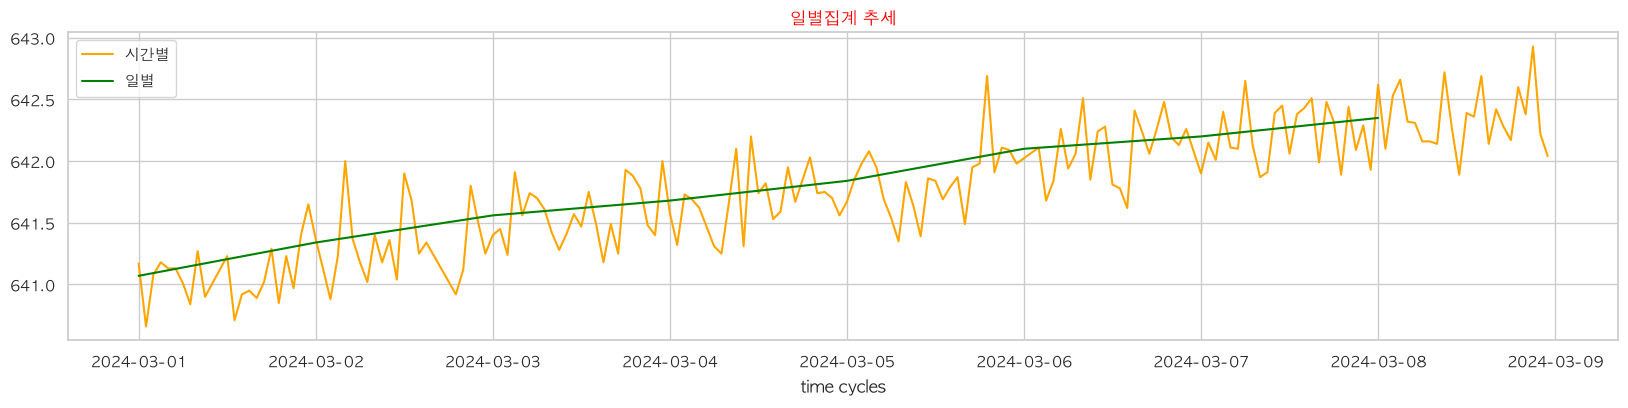

In [365]:
daily = data_timestamp["temp_out"].resample("1D").mean().round(2)

print(daily.head(3))

plt.figure(figsize=(20,4))

plt.title("일별집계 추세", color = "red")
plt.plot(data_timestamp.index, 
         data_timestamp["temp_out"],
         color = "orange",
         label = "시간별")
plt.plot(daily.index, 
         daily.values,
         color = "green",
         label = "일별")
plt.legend()
plt.xlabel("time cycles")

plt.show()

## 실습 8. 업샘플링 결측과 보간
### 목표
업샘플링으로 생기는 결측과 원본의 기존 결측을 보간으로 채우기
### 단계
- 30분 단위로 촘촘하게 만들어 생긴 결측 세기
- 보간으로 빈 값을 채우고 결측이 0이 됨을 확인
- 원본에 원래 있던 결측도 보간으로 메우기
### 예상 결과
업샘플링 결측 201이 보간 후 0, 진동 원본 결측 3도 0

In [366]:
print(f"원본 결측 : {data_timestamp.isna().sum().sum()}")
print("="*20)
up=data_timestamp["temp_out"].resample("30min").mean()

print(up.head())
print("="*20)
print(f"업샘플링 결측 : {up.isna().sum().sum()}")
print(f"업샘플링 보간 후 결측 : {up.interpolate().isna().sum().sum()}")


print("="*20)
print(f"진동 결측 : {data_timestamp["vibration"].isna().sum().sum()}")
print(f"업샘플링 보간 후 결측 : {data_timestamp["vibration"].interpolate().isna().sum().sum()}")


원본 결측 : 5
timestamp
2024-03-01 00:00:00    641.17
2024-03-01 00:30:00       NaN
2024-03-01 01:00:00    640.66
2024-03-01 01:30:00       NaN
2024-03-01 02:00:00    641.08
Freq: 30min, Name: temp_out, dtype: float64
업샘플링 결측 : 201
업샘플링 보간 후 결측 : 0
진동 결측 : 3
업샘플링 보간 후 결측 : 0


## 실습 1. 센서 시계열 그려보기
### 목표
한 엔진의 센서 값을 회차 순서대로 선 그래프로 그려 변화 방향 읽기
### 단계
- 2번 엔진을 골라 회차를 가로축으로 준비
- 센서 하나를 선 그래프로 그리기
- 제목·축 이름을 붙이고 값이 오르내리는 방향 읽기
### 예상 결과
회차가 늘수록 값이 서서히 오르는 곡선

In [367]:
df = pd.read_csv("data/21_cmapss_fd001_sample.csv")
print(df.shape)
print(df.columns)

# 결측 확인
print(df.isna().sum().sum())

(1031, 10)
Index(['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_2',
       's_3', 's_4', 's_7', 's_11'],
      dtype='str')
0


(287, 10)
192    1399.71
193    1400.55
194    1398.30
195    1401.12
196    1399.49
Name: s_4, dtype: float64


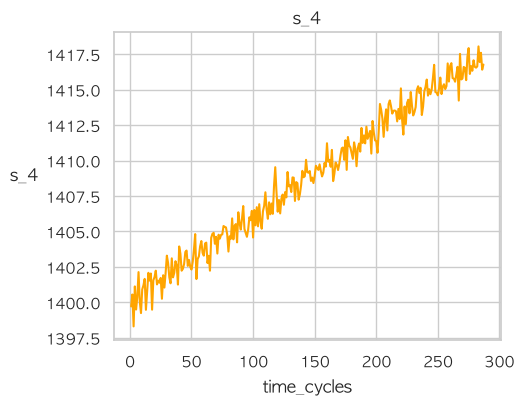

In [368]:
engine2 = df[df['unit_nr'] == 2]
print(engine2.shape)
print(engine2['s_4'].head())

plt.figure(figsize=(5,4))
plt.title('s_4')
plt.plot(engine2['time_cycles'], engine2['s_4'], color ="orange")
plt.xlabel('time_cycles')
plt.ylabel('s_4', rotation=0, labelpad=15)
plt.show()

## 실습 2. 이동평균선으로 추세 보기
### 목표
떨리는 원본 위에 매끈한 이동평균선을 겹쳐 추세를 드러내기
### 단계
- 창 크기 10으로 이동평균을 구하기
- 원본과 이동평균을 한 그래프에 겹쳐 그리기
- 범례를 붙이고 이동평균이 추세를 드러냄을 확인
### 예상 결과
들쭉날쭉한 원본 사이로 매끈한 상승 추세선

474    1416.927
475    1416.890
476    1416.857
477    1416.887
478    1416.898
Name: s_4, dtype: float64
9


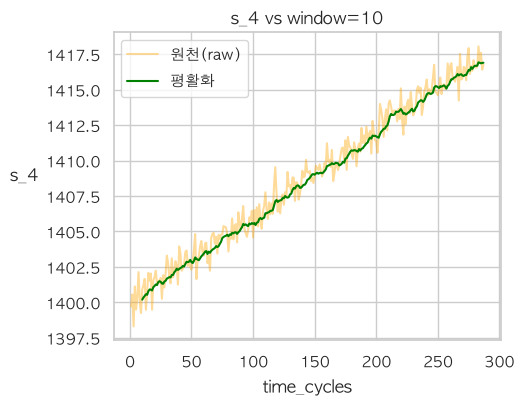

In [369]:
move10 = engine2['s_4'].rolling(window=10).mean()
print(move10.tail())
print(move10.isna().sum().sum())

plt.figure(figsize=(5,4))
plt.title('s_4 vs window=10')
plt.plot(engine2['time_cycles'], engine2['s_4'], label='원천(raw)', color="orange", alpha=0.4)
plt.plot(engine2['time_cycles'], move10, label='평활화', color="green")
plt.legend()
plt.xlabel('time_cycles')
plt.ylabel('s_4', rotation=0, labelpad=15)
plt.show()

## 실습 3. 윈도우 크기 바꿔 비교하기
### 목표
창 크기를 5·20·50으로 바꿔 매끈함과 빈 구간의 맞교환을 관찰
### 단계
- 원본을 옅게 그린 뒤 세 가지 창 크기 이동평균을 겹치기
- 창이 클수록 더 매끄럽지만 앞쪽 빈 구간이 긺을 확인
- 범례로 어느 선이 어느 창인지 구분
### 예상 결과
창이 클수록 매끈하지만 시작 부분 빈 구간이 늘어남

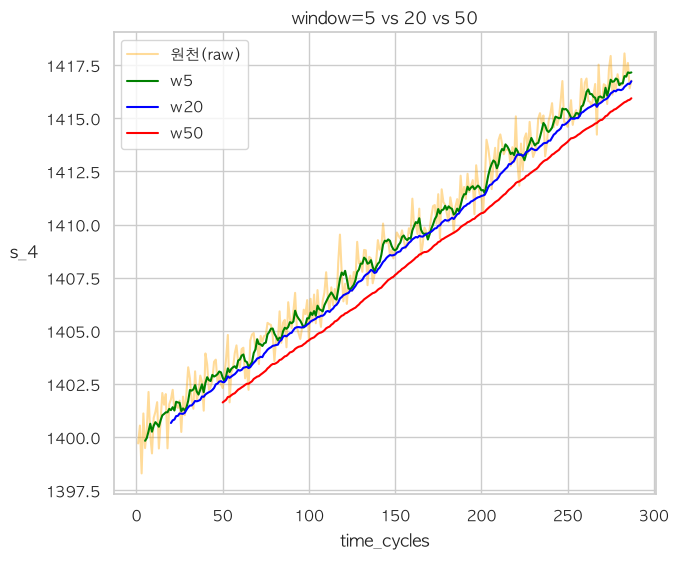

In [370]:
move5 = engine2["s_4"].rolling(window=5).mean()
move20 = engine2["s_4"].rolling(window=20).mean()
move50 = engine2["s_4"].rolling(window=50).mean()

plt.figure(figsize=(7,6))
plt.title('window=5 vs 20 vs 50')
plt.plot(engine2['time_cycles'], engine2['s_4'], label='원천(raw)', color="orange", alpha=0.4)
plt.plot(engine2['time_cycles'], move5, label='w5', color = "green")
plt.plot(engine2['time_cycles'], move20, label='w20', color = "blue")
plt.plot(engine2['time_cycles'], move50, label='w50',color = "red")
plt.legend()
plt.xlabel('time_cycles')
plt.ylabel('s_4', rotation=0, labelpad=15)
plt.show()

## 실습 4. 여러 센서 추세 방향 비교
### 목표
여러 센서의 이동평균을 함께 그려 상승·하강 방향을 비교
### 단계
- 대상 센서마다 창 크기 20 이동평균을 구하기
- 한 그래프에 겹쳐 그리고 범례를 붙이기
- 각 센서가 오르는지 내리는지 방향 판정
### 예상 결과
어떤 센서는 상승, 어떤 센서는 하강하는 서로 다른 방향

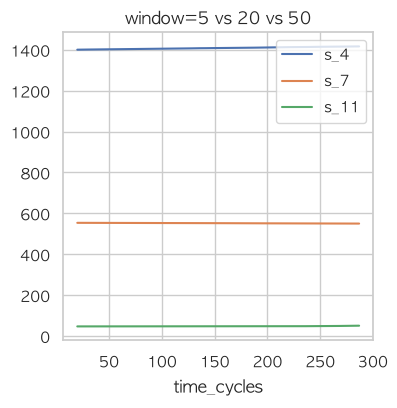

In [371]:
sensors = ['s_4', 's_7', 's_11']

plt.figure(figsize=(4,4))
plt.title('window=5 vs 20 vs 50')

for sensor in sensors:
  move20 = engine2[sensor].rolling(window=20).mean()
  plt.plot(engine2['time_cycles'], move20, label=sensor,)

plt.legend()
plt.xlabel('time_cycles')
plt.show()


## 실습 5. 이동표준편차로 변동성 구간 찾기
원본과 이동표준편차를 위아래로 나눠 그려 구간 찾기
### 목표
원본과 이동표준편차를 위아래로 나눠 그려 흔들림이 큰 구간을 찾기
### 단계
- 창 크기 20으로 이동표준편차를 구하기
- 위칸에 원본, 아래칸에 이동표준편차를 그리기
- 표준편차가 치솟는 구간을 변동성이 큰 구간으로 표시
### 예상 결과
- 후반부에서 이동표준편차가 커지는 불안정 구간

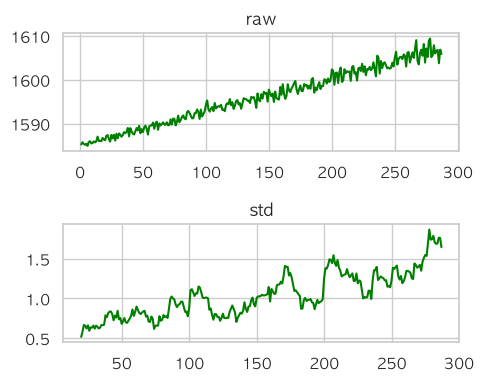

In [372]:
std20 = engine2['s_3'].rolling(window=20).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5,4))

ax1.set_title('raw')
ax1.plot(engine2['time_cycles'], engine2['s_3'], color = "green")

ax2.set_title('std')
ax2.plot(engine2['time_cycles'], std20, color = "green")

plt.tight_layout()
plt.show()

## 실습 6. 평균과 변동성 밴드 함께 그리기
이동평균선에 표준편차 두 배 띠를 둘러 정상 범위 보기
### 목표
이동평균선에 표준편차 두 배 띠를 둘러 정상 범위를 시각화
### 단계
- 창 크기 20으로 이동평균과 이동표준편차를 구하기
- 원본과 이동평균을 그리기
- 평균에 표준편차 두 배를 더하고 뺀 띠를 색으로 채우기
### 예상 결과
- 이동평균 주위로 폭이 변하는 정상 범위 띠

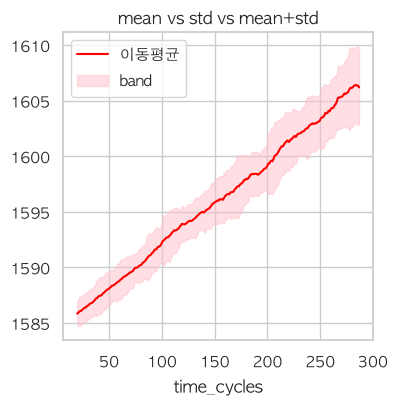

In [373]:
#이동평균
ma = engine2['s_3'].rolling(window=20).mean()

#이동표준편차
std = engine2['s_3'].rolling(window=20).std()

plt.figure(figsize=(4,4))
plt.title('mean vs std vs mean+std')

# plt.plot(engine2['time_cycles'], engine2['s_3'], label='이동평균')
plt.plot(engine2['time_cycles'], ma, label='이동평균', color = "red")
# plt.plot(engine2['time_cycles'], std, label='이동표준편차')

top = ma + 2 * std
bottom = ma - 2 * std

plt.fill_between(engine2['time_cycles'], bottom, top, alpha=0.5, label='band', color = "pink")

plt.legend()
plt.xlabel('time_cycles')
plt.show()

## 실습 7. 변동성 패턴 해석
여러 센서의 이동표준편차로 점증·급증 패턴 비교
### 목표
여러 센서의 이동표준편차를 나눠 그려 점증·급증 패턴을 비교
### 단계
- 대상 센서마다 창 크기 20 이동표준편차를 구하기
- 센서별로 칸을 나눠 각각 그리기
- 서서히 커지는 점증과 갑자기 튀는 급증을 구분
### 예상 결과
- 센서마다 다른 변동성 패턴 — 완만한 증가와 급한 튐

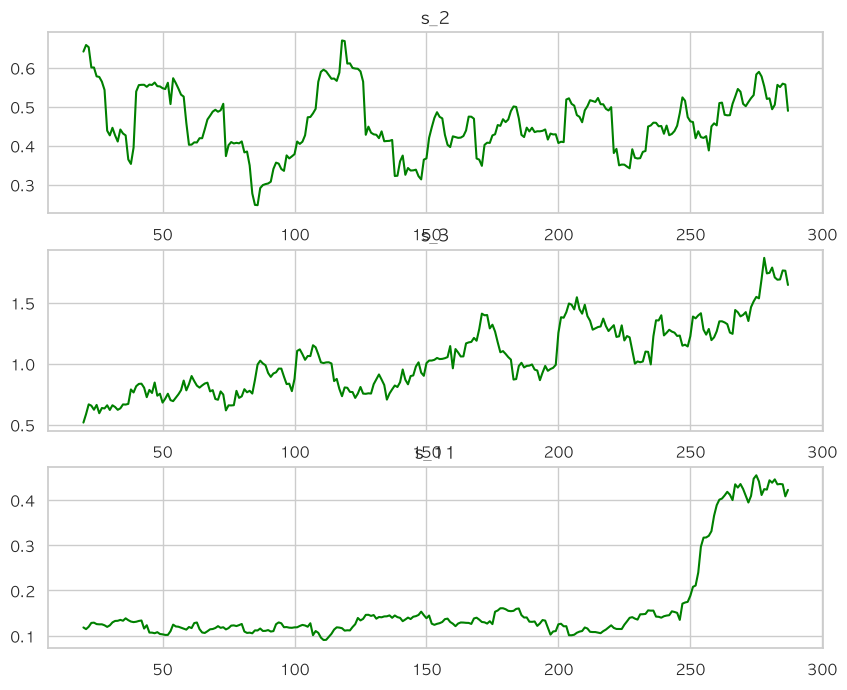

<Figure size 400x400 with 0 Axes>

In [374]:
sensors = ['s_2', 's_3', 's_11']


fig, axes = plt.subplots(3, 1, figsize=(10,8))

plt.figure(figsize=(4,4))

for ax, sensor in zip(axes, sensors):
  std20 = engine2[sensor].rolling(window=20).std()
  ax.plot(engine2['time_cycles'], std20, label=sensor, color = "green")

  ax.set_title(sensor)

plt.tight_layout()
plt.show()

## 실습 1. 변화량으로 급변 탐지하기
### 목표
직전 대비 변화량으로 원본에서 안 보이던 급변 시점을 찾기
### 단계
- 2번 엔진 센서의 직전 대비 변화량을 구하기
- 위칸에 원본, 아래칸에 변화량과 0 기준선을 그리기
- 0에서 크게 벗어난 회차를 급변 시점으로 표시
### 예상 결과
변화량 그래프에서 0을 크게 벗어난 몇몇 회차가 급변 후보

In [375]:
df = pd.read_csv("data/21_cmapss_fd001_sample.csv")
print(df.shape)
print(df.columns)

# 결측 확인
print(df.isna().sum().sum())

(1031, 10)
Index(['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_2',
       's_3', 's_4', 's_7', 's_11'],
      dtype='str')
0


(287, 10)


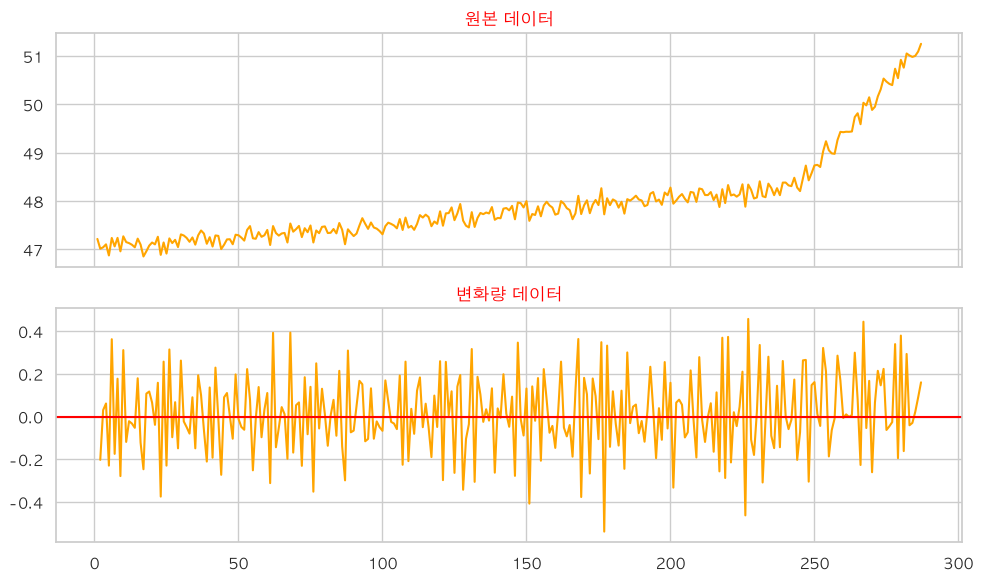

0.54


In [376]:
engine2 = df[df["unit_nr"]==2]
print(engine2.shape)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10,6), sharex=True)

ax1.set_title("원본 데이터", color = "red")
ax1.plot(engine2["time_cycles"], engine2["s_11"], color="orange")


ax2.set_title("변화량 데이터", color = "red")
diff = engine2["s_11"].diff()
ax2.plot(engine2["time_cycles"], diff, 
         color="orange")
ax2.axhline(0, color = "red") # 0 기준선

plt.tight_layout()
plt.show()

print(round(diff.abs().max(), 2))

## 실습 2. 추세·변동성·변화량 종합 관찰
### 목표
한 센서를 추세·변동성·변화량 세 관점으로 한 화면에서 관찰
### 단계
- 이동평균으로 추세, 이동표준편차로 변동성, 변화량으로 급변을 각각 구하기
- 세 칸으로 나눠 원본과 추세, 변동성, 변화량을 그리기
- 세 관점을 종합해 센서 상태를 한두 문장으로 정리
### 예상 결과
추세는 완만한 상승, 변동성·변화량은 후반에 커지는 신호

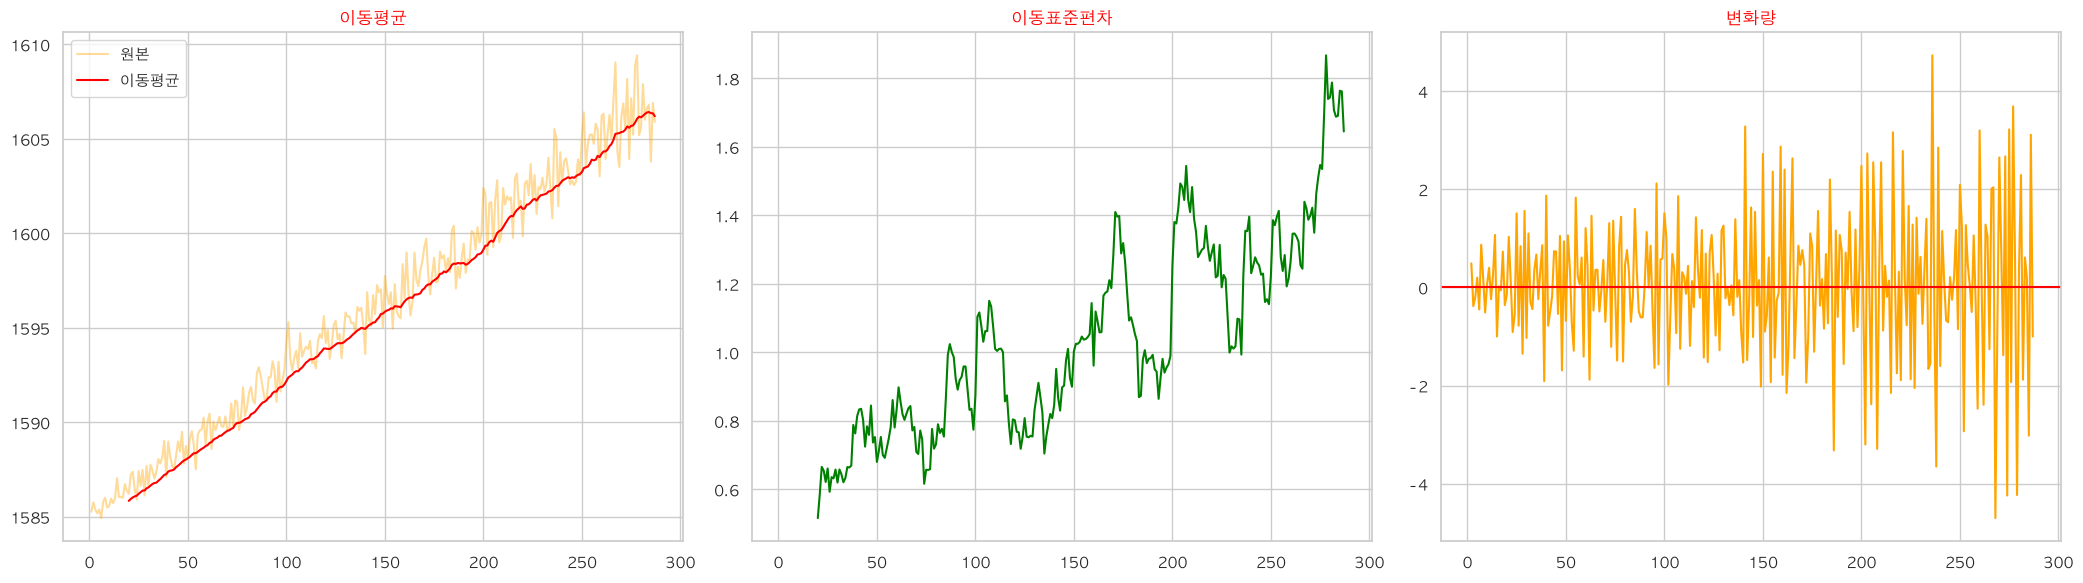

In [377]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (21,6), sharex = True)

ax1.set_title("이동평균", color = "red")
ma = engine2["s_3"].rolling(20).mean()
ax1.plot(engine2["time_cycles"], engine2["s_3"], 
         color="orange",
         label = "원본",
         alpha = 0.4)
ax1.plot(engine2["time_cycles"], ma, 
         color="red",
         label = "이동평균")
ax1.legend()


ax2.set_title("이동표준편차", color = "red")
std = engine2["s_3"].rolling(20).std()
ax2.plot(engine2["time_cycles"], std, 
         color="green",
         label = "이동표준편차")
ax1.legend()

ax3.set_title("변화량", color = "red")
diff = engine2["s_3"].diff()
ax3.plot(engine2["time_cycles"], diff, 
         color="orange")
ax3.axhline(0, color = "red") # 0 기준선

plt.tight_layout()
plt.show()

## 실습 3. 시간 단위 추세 보기
### 목표
가로축을 진짜 날짜·시각으로 만들어 원본과 이동평균 추세를 보기
### 단계
- 시각 글자를 시각 값으로 바꿔 인덱스로 올리기
- 원본을 옅게, 시간 이동평균을 진하게 겹쳐 그리기
- 가로축이 실제 시각인 추세선을 읽기
### 예상 결과
날짜 가로축 위로 매끈하게 상승하는 이동평균선

In [378]:
df = pd.read_csv("data/21_engine1_timestamp_sample.csv", encoding = "UTF-8")

print(df.shape)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df_timestamp = df.copy()
df_timestamp = df_timestamp.set_index("timestamp").sort_index()

print(df_timestamp.head(3))

(192, 6)
                        s_2      s_3      s_4     s_7    s_11
timestamp                                                    
2024-01-01 00:00:00  640.69  1585.21  1399.30  554.17  46.931
2024-01-01 01:00:00  641.13  1585.55  1401.18  554.36  46.857
2024-01-01 02:00:00  641.25  1584.72  1400.84  554.00  47.220


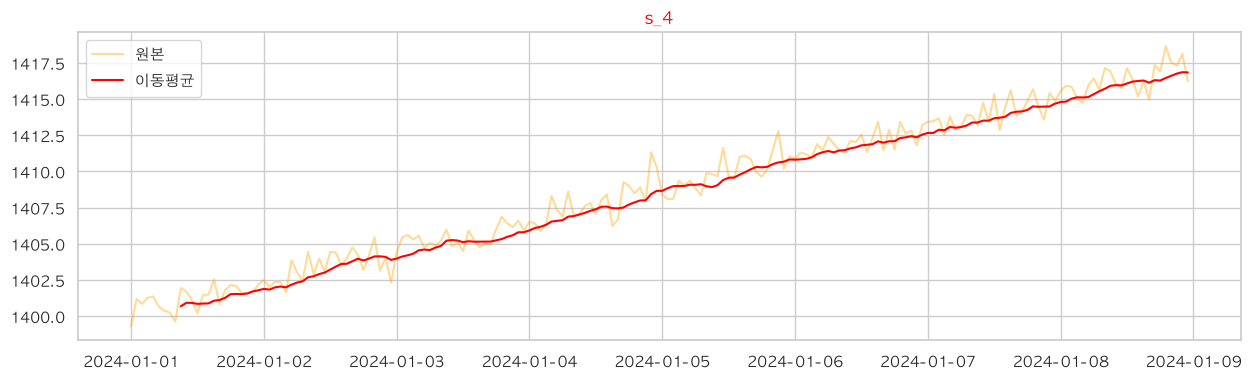

In [379]:
plt.figure(figsize=(15,4))
plt.title("s_4", color = "red")
plt.plot(df_timestamp.index, df_timestamp["s_4"], 
         label = "원본",
         color = "orange",
         alpha = 0.4)
plt.plot(df_timestamp.index, df_timestamp["s_4"].rolling(10).mean(), 
         label = "이동평균",
         color = "red")

plt.legend()

## 실습 4. 시간 단위 집계로 주기 패턴 보기
### 목표
원본·6시간·하루 평균을 겹쳐 리샘플링이 큰 패턴을 드러냄을 확인
### 단계
- 시각 인덱스 데이터에서 6시간·하루 단위 평균을 각각 구하기
- 원본과 두 집계를 한 그래프에 겹쳐 그리기
- 단위가 커질수록 잔잔해지며 큰 흐름이 드러남을 확인
### 예상 결과
하루 평균은 8개 점으로, 원본의 잔떨림이 사라진 매끈한 흐름

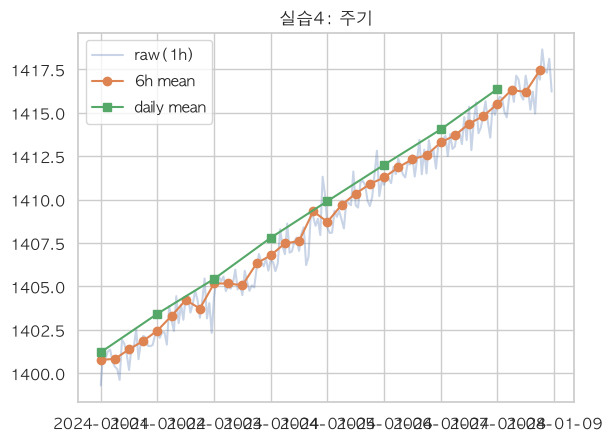

하루 평균 개수: 8


In [380]:
# [다운샘플링 주기에 따른 시계열의 주기적(Periodicity) 변동 관찰]
# 1. resample('6h').mean(): 6시간 단위로 축약하여 교대 근무 단위의 변동 패턴을 요약합니다.
# 2. resample('D').mean(): 하루('D', Day) 단위의 데이터를 요약하여 일별 등락만을 강조합니다.
# * 1시간 단위 신호에서 주기적으로 반복되는 일일 부하 변동(예: 낮에 운전이 많고 밤에 적어 온도가 오르내림)을
#   6시간 및 하루 평균선으로 축약하여 노이즈를 필터링하고 장기 운전 주기를 검증합니다.
# * `marker='o'`, `marker='s'` 등 마커 속성을 부여해 선 위에 샘플링 시점(점, 사각형)을 명시적으로 찍으면,
#   데이터 해상도가 얼만큼 거칠어졌는지 시각적으로 쉽게 비교할 수 있습니다.

h6 = df_timestamp['s_4'].resample('6h').mean() # 6시간 단위
day = df_timestamp['s_4'].resample('D').mean() # 하루 단위 

plt.plot(df_timestamp.index, df_timestamp['s_4'], alpha=0.3, label='raw(1h)')
plt.plot(h6.index, h6, marker='o', label='6h mean')
plt.plot(day.index, day, marker='s', label='daily mean')
plt.legend()
plt.title('실습4: 주기')
plt.show()

print('하루 평균 개수:', len(day))

## 실습 5. 누락 시점 보간 후 재분석
### 목표
누락을 만들고 채우는 방법에 따라 결과가 어떻게 다른지 비교
### 단계
- 작은 예시에서 앞값 채움과 선형 보간의 결과 차이를 비교
- 시각 데이터 일부를 일부러 비우고 누락 개수를 확인
- 보간으로 채운 뒤 누락이 사라졌는지 확인
### 예상 결과
앞값 채움은 계단 모양, 선형 보간은 12·14로 이어짐; 보간 후 0

In [381]:
# [결측치 보정 기법 — 직전값 대체(ffill) vs 선형보간(interpolate)]
# 1. ffill() (Forward Fill): 가장 최근에 정상 측정된 앞의 값을 그대로 끌어다 결측 구간에 덮어씁니다.
# 2. interpolate() (Linear Interpolation): 결측 구간의 이전 정상값과 이후 정상값 사이를 일정한 경사로 이어 채웁니다.
# 3. s2.iloc[50:55] = np.nan: 의도적으로 5개 행에 결측을 주입한 후 interpolate를 통해 복원 테스트를 진행합니다.
# * 통신 장비 오류나 센서 재부팅으로 인해 누락된 구간이 존재하면 분석 함수(특히 시계열 분해나 머신러닝)가
#   작동하지 않고 에러를 내므로, 시간적 흐름에 부합하도록 주변 수치를 추정하여 견고하게 결측을 제거해야 합니다.
# * ffill()과 interpolate() 모두 복원 결과를 기존 시리즈나 데이터프레임에 재할당해주거나
#   `inplace=True` 파라미터를 넘겨주어야 원본이 수정됩니다.

s = pd.Series([10.0, np.nan, np.nan, 16.0, 18.0])
print('ffill:', s.ffill().tolist())
print('interpolate:', s.interpolate().tolist())

s2 = df_timestamp['s_4'].copy(); s2.iloc[50:55] = np.nan
print('누락 개수:', int(s2.isna().sum()))
print('보간 후:', int(s2.interpolate().isna().sum()))

ffill: [10.0, 10.0, 10.0, 16.0, 18.0]
interpolate: [10.0, 12.0, 14.0, 16.0, 18.0]
누락 개수: 5
보간 후: 0


## 실습 6. 시계열 분해 시연·관찰
### 목표
시계열을 원본·추세·주기·나머지 네 부분으로 분해해 관찰(강사 시연)
### 단계
- 분해 도구로 시각 데이터를 더하기 모형으로 분해
- 원본·추세·계절·잔차 네 칸을 함께 보기
- 추세 칸이 이동평균 추세와 비슷한지 비교
### 예상 결과
네 칸으로 나뉜 분해 결과 — 추세는 상승, 주기는 반복 무늬

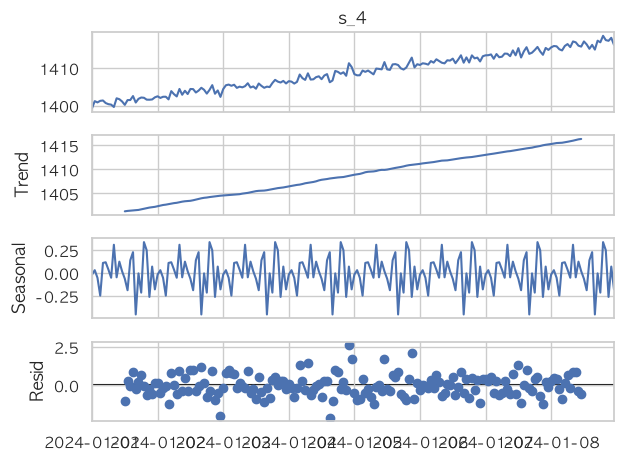

In [382]:
# [시계열 분해(Seasonal Decomposition)를 통한 시계열 구성 성분 추출]
# 1. seasonal_decompose: 신호를 장기 추세(Trend), 반복 주기(Seasonal), 그리고 무작위 잡음(Residual)의 합(additive)으로 분해합니다.
# 2. period=24: 매시 수집된 데이터에서 하루 주기(24시간)의 계절성이 반복된다고 명시적으로 정의합니다.
# * 센서 데이터에 복합적으로 꼬여있는 노이즈(Residual)와 근무 교대 주기(Seasonal)를 각각 분리하고,
#   오로지 기계의 노화 속도를 대변하는 순수 장기 신호(Trend)만 필터링하여 남기기 위한 통계적 전처리 기술입니다.
# * statsmodels의 seasonal_decompose는 데이터 내에 NaN(결측치)이 포함되어 있으면 실행 도중 에러를 유발하므로,
#   반드시 `interpolate()` 등으로 결측치를 완전 보정한 정제 상태에서 호출해야 합니다.

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df_timestamp['s_4'], model='additive', period=24)
result.plot()
plt.tight_layout()
plt.show()

In [383]:
df = pd.read_csv('data/21_cmapss_fd001_sample.csv')
print(df.shape)

sensors = ['s_2', 's_3', 's_4', 's_7', 's_11']

(1031, 10)


## 실습 1. 상관관계 heatmap 해석하기
여러 센서의 상관을 색으로 그려 관계 파악

목표
- 여러 센서의 상관 heatmap을 그려 함께 움직이는 센서를 색으로 파악

단계
- 다섯 센서의 상관행렬을 계산
- 히트맵으로 색과 숫자를 함께 표시
- 대각선을 빼고 진한 칸을 강한 관계로 읽기

예상 결과
- 진한 칸이 강한 양·음 상관, s_2와 s_4가 가장 진함

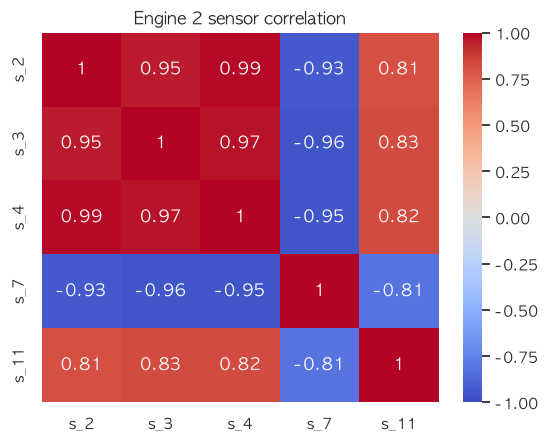

In [384]:
# [2번 엔진의 주요 센서 간 상관관계 행렬 시각화]
# 1. sns.heatmap(): 2번 엔진 센서 간 상관관계의 크기를 색상 강도로 매핑하고, 수치 값을 셀에 오버레이합니다.
# 2. vmin=-1, vmax=1: 색상 범위를 피어슨 상관계수 한계치인 -1(완벽한 음)부터 +1(완벽한 양)로 제한하여 왜곡을 없앱니다.
# * 어떤 센서들이 서로 완전히 똑같이 행동하는지(예: s_2와 s_4가 약 0.99로 극도의 양의 상관),
#   어떤 센서가 서로 상반되는 움직임을 띄는지 파악하여 향후 고장 모델 입력 피처 선택의 우선순위를 결정합니다.
# * 히트맵을 렌더링하고 `plt.close()`를 수행해야 다음 실습 도화지와 격리되어 이미지가 혼선 없이 깔끔하게 저장됩니다.

e2 = df[df['unit_nr'] == 2].reset_index(drop=True)
sns.heatmap(e2[sensors].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Engine 2 sensor correlation')
plt.show()

## 실습 2. 강하게 연동된 센서 묶음 찾기
상관 절대값이 큰 센서쌍만 골라 핵심 묶음 식별

목표
- 상관 절대값이 큰 센서쌍만 골라 핵심 연동 묶음을 식별

단계
- 상관행렬에서 두 센서씩 짝지어 상관을 확인
- 절대값이 0.9 이상인 쌍만 골라내기
- 양의 묶음과 음의 묶음으로 나눠 정리

예상 결과
- s_2·s_3·s_4가 강한 양의 묶음, s_7은 이들과 음의 관계

In [385]:
# [중첩 루프(Nested Loop)를 이용한 고상관 센서 조합 자동 식별]
# 1. 이중 for 루프: 행렬의 대각 성분을 기준으로 우상단 삼각형 영역만 순회하여 중복 매칭을 사전에 피합니다 (`j = i + 1` 기법).
# 2. abs(c) >= 0.9: 양의 상관과 음의 상관을 아울러 절댓값 0.9 이상의 초강력 상호작용을 가진 센서 쌍만 발라냅니다.
# * 설비 진단 엔지니어가 수많은 측정 지표 속에서 동조하는 물리량 묶음(예: 온도 상승과 입력 마찰의 동시 증가)을
#   수작업 대신 코드로 즉시 식별하여 물리적 다중공선성 문제를 계량적으로 제어하기 위해 활용됩니다.
# * `iloc[i, j]`를 조회할 때 인덱서 변수의 대소문자나 오타에 주의하고,
#   중복 출력을 피하려면 안쪽 루프의 시작점 j가 반드시 `i + 1`이 되도록 코딩해야 합니다.

corr = e2[sensors].corr()
for i in range(len(sensors)):
    for j in range(i + 1, len(sensors)):
        c = corr.iloc[i, j]
        if abs(c) >= 0.9:
            print(sensors[i], '-', sensors[j], ':', round(c, 2))


s_2 - s_3 : 0.95
s_2 - s_4 : 0.99
s_2 - s_7 : -0.93
s_3 - s_4 : 0.97
s_3 - s_7 : -0.96
s_4 - s_7 : -0.95


## 실습 3. 이상 의심 구간 표시하기
이동표준편차로 변동성을 추적하고 의심 구간 색칠

목표
- 이동표준편차로 변동성을 추적하고 의심 구간을 색으로 표시

단계
- 창 크기 20으로 이동표준편차를 구하기
- 위칸에 원본, 아래칸에 이동표준편차를 그리기
- 변동성이 커지는 후반 구간을 색 영역으로 표시

예상 결과
- 후반 구간에서 이동표준편차가 치솟고 색칠된 의심 구간과 겹침

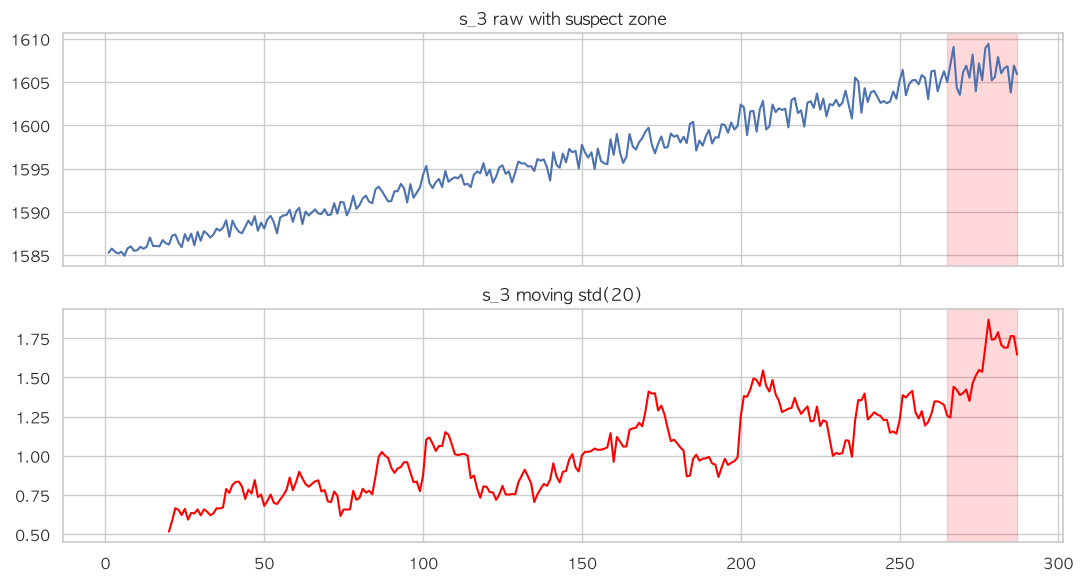

In [386]:
# [axvspan을 이용한 시계열 이상 의심 구간 시각적 음영 하이라이트]
# 1. std20: 20-사이클 이동표준편차 변동성 시리즈를 정의합니다.
# 2. ax1.axvspan(265, 287): x축의 265 사이클부터 287 사이클까지의 배경에 옅은 빨간색 영역(Span)을 생성합니다.
# 3. sharex=True: 위아래 두 서브플롯의 가로축을 강제 바인딩하여 마우스 줌이나 플로팅 범위를 동기화합니다.
# * 엔진이 수명 임계치 근처에 다다라 급격한 진동(이동표준편차 피크)을 나타내는 고장 임박 구간을
#   관람자에게 직관적이고 경고 효과를 주기 위해 차트에 음영으로 배경을 도포해 줍니다.
# * `alpha=0.15`와 같이 투명도를 낮추지 않고 불투명하게(1.0) 그리면
#   배경이 원본 그래프 선을 완전히 덮어써 보이지 않게 되는 실수가 흔히 발생합니다.

std20 = e2['s_3'].rolling(20).std()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.plot(e2['time_cycles'], e2['s_3'])
ax1.axvspan(265, 287, color='red', alpha=0.15)
ax1.set_title('s_3 raw with suspect zone')

ax2.plot(e2['time_cycles'], std20, color='red')
ax2.axvspan(265, 287, color='red', alpha=0.15)
ax2.set_title('s_3 moving std(20)')

plt.tight_layout()
plt.show()

## 실습 4. 정상 범위 벗어난 점 찾기
평균과 표준편차로 정상 범위를 만들고 벗어난 점 세기

목표
- 평균과 표준편차로 정상 범위를 만들고 벗어난 점을 세기

단계
- 센서의 평균과 표준편차를 구하기
- 평균에 표준편차 두 배를 더하고 뺀 정상 범위를 만들기
- 정상 범위를 벗어난 점의 개수를 세기

예상 결과
- 정상 범위는 약 1583~1609, 벗어난 점은 2개

In [387]:
# [표준편차 경계선 수립 및 초기 신품 통계 기준선 확보]
# 1. mean() $\pm$ 2*std()를 통해 데이터 전체 평균을 기반으로 하는 신뢰 통계적 정상 임계 대역을 계산합니다.
# 2. e2['s_3'] 센서에서 이 임계 범위(lower ~ upper)를 탈출한 극단치 데이터 포인트를 선별합니다.
# 3. s.iloc[:50].mean(): 기계가 처음 출하되어 안정적인 구동을 보이는 신품 시점(초반 50 사이클)의 기준선(Baseline)을 연산합니다.
# * 기계 초기 가동 시의 기준치와 전체 수명 대비 이상 탈출 빈도를 분석함으로써,
#   장비 열화 속도의 가속 여부를 모니터링할 때 필요한 초기 정량 기준을 제공합니다.
# * 이상치 검출 수식 작성 시 괄호 우선순위와 논리 OR 기호인 `|`를 누락하면 원치 않는 연산 오류를 보게 됩니다.

s = e2['s_3']
m, sd = s.mean(), s.std()
lower, upper = m - 2*sd, m + 2*sd
print('정상 범위:', round(lower, 2), '~', round(upper, 2))

out = ((s > upper) | (s < lower)).sum()
print('벗어난 점:', int(out))
print('초반50 기준 평균:', round(s.iloc[:50].mean(), 2))

정상 범위: 1583.17 ~ 1608.94
벗어난 점: 2
초반50 기준 평균: 1586.96


## 실습 5. 종합 분석 리포트
한 엔진을 추세·변동성·상관까지 분석하고 리포트로 정리

목표
- 배운 도구로 한 엔진을 추세·변동성·상관까지 분석하고 리포트로 정리

단계
- 추세와 변동성 그래프를 그리고 의심 구간을 표시
- 상관 heatmap으로 센서 관계를 확인
- 사실과 해석을 구분한 짧은 리포트 출력

예상 결과
- 그래프·heatmap과 함께 사실·해석이 구분된 미니 리포트

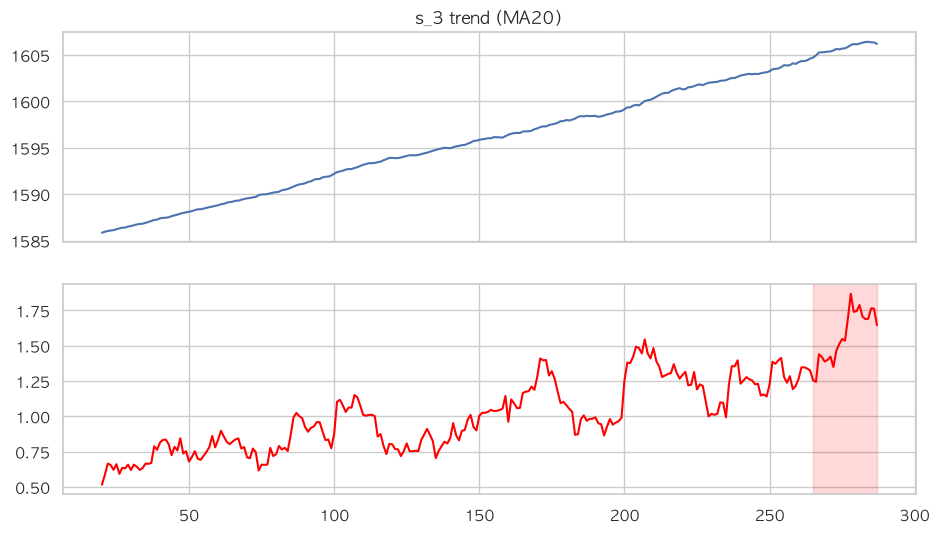

[사실] s_3 변동성이 후반부(265주기 이후) 증가
[사실] s_2-s_4 상관 0.99, s_2-s_7 상관 -0.93
[해석] 후반부 열화 진행 의심 -> 관찰 강화 권고


In [388]:
# [통계 및 시각화 근거 기반 설비 보전 의사결정 요청용 종합 리포트 생성]
# 1. axes[0].plot(): 20-사이클 이동평균선(ma)을 통해 온도/마찰 센서의 지속적인 우상향(추세)을 증명합니다.
# 2. axes[1].plot() 및 axvspan(): 후반부(265~287 사이클)에 발생한 진폭 팽창(변동성 급증) 현상을 차트상에 경고 박스로 매핑합니다.
# 3. 종합 인쇄문: 앞서 발견한 정량 사실들(상관행렬 결과, 변동 구간)을 텍스트로 구성하고 최종 정비 권고안을 현장에 송출합니다.
# * 머신러닝이나 수식을 통한 기계 예측 과정에서 수치뿐 아니라 원인과 경과를 설명할 수 있는
#   '설명 가능한(Explainable) 예방보전'의 기초 형태를 텍스트 및 차트 리포트로 자동 생성해 줍니다.
# * 리포트 문자열 출력 시, 줄바꿈이나 오타로 인해 코드 블록 문법이 망가지지 않도록 세심하게 텍스트를 인쇄합니다.

ma = e2['s_3'].rolling(20).mean()
sd2 = e2['s_3'].rolling(20).std()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(e2['time_cycles'], ma); axes[0].set_title('s_3 trend (MA20)')
axes[1].plot(e2['time_cycles'], sd2, color='red')
axes[1].axvspan(265, 287, color='red', alpha=0.15)

plt.show()

print('[사실] s_3 변동성이 후반부(265주기 이후) 증가')
print('[사실] s_2-s_4 상관 0.99, s_2-s_7 상관 -0.93')
print('[해석] 후반부 열화 진행 의심 -> 관찰 강화 권고')